# MNQ Candle Body Analysis — Normalized
Open-to-close range across 96.7M bars (2019-2025). All metrics unitless.

In [1]:
import io
import urllib.request
import urllib.parse
import json
from pathlib import Path

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.style.use('dark_background')
plt.rcParams['figure.figsize'] = (16, 6)
plt.rcParams['font.size'] = 11

QUESTDB_HOST = "127.0.0.1"
QUESTDB_PORT = "9000"
TICK_SIZE = 0.25
OUTPUT_DIR = Path(r"E:\source\repos\ml_dashboard\data\candle_analysis\MNQ")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def query_questdb(sql: str) -> pl.DataFrame:
    """Load query results from QuestDB HTTP /exp as polars DataFrame."""
    url = f"http://{QUESTDB_HOST}:{QUESTDB_PORT}/exp?query={urllib.parse.quote(sql)}"
    with urllib.request.urlopen(url, timeout=600) as resp:
        csv_bytes = resp.read()
    if len(csv_bytes) < 10:
        return pl.DataFrame()
    return pl.read_csv(io.BytesIO(csv_bytes), try_parse_dates=True)

print("Ready")

Ready


## 1. Load All MNQ 1-Minute Data

In [2]:
# Load year-by-year to avoid HTTP timeout
frames = []
for year in range(2019, 2026):
    sql = f"""
    SELECT timestamp, open, high, low, close, volume
    FROM ohlcv
    WHERE symbol = 'MNQ'
      AND timestamp >= '{year}-01-01T00:00:00.000000Z'
      AND timestamp <  '{year+1}-01-01T00:00:00.000000Z'
    ORDER BY timestamp
    """
    chunk = query_questdb(sql)
    if len(chunk) > 0:
        frames.append(chunk)
        print(f"  {year}: {len(chunk):>12,} bars")

df = pl.concat(frames)
print(f"\nTotal: {len(df):,} bars | {df['timestamp'].min()} to {df['timestamp'].max()}")

  2019:    4,525,069 bars


  2020:   14,267,138 bars


  2021:   13,982,304 bars


  2022:   16,765,161 bars


  2023:   14,564,273 bars


  2024:   15,712,991 bars


  2025:   16,918,693 bars

Total: 96,735,629 bars | 2019-05-05 15:03:17+00:00 to 2025-12-30 15:59:55+00:00


In [3]:
# Compute normalized (unitless) metrics
# body = |close - open|, range = high - low
# All converted to ratios against the global mean — no price, no ticks

body_raw = (df["close"] - df["open"]).abs()
range_raw = df["high"] - df["low"]

# Global means (the baseline)
body_mean = body_raw.mean()
body_std = body_raw.std()
range_mean = range_raw.mean()
range_std = range_raw.std()

df = df.with_columns([
    body_raw.alias("body_raw"),
    range_raw.alias("range_raw"),
    # Ratio vs global mean (1.0 = average, 2.0 = 2x average)
    (body_raw / body_mean).alias("body_ratio"),
    (range_raw / range_mean).alias("range_ratio"),
    # Z-score (std devs from mean)
    ((body_raw - body_mean) / body_std).alias("body_z"),
    ((range_raw - range_mean) / range_std).alias("range_z"),
    # Body as fraction of total candle range (0-1, how much is body vs wick)
    pl.when(range_raw > 0)
      .then(body_raw / range_raw)
      .otherwise(0.0)
      .alias("body_pct_of_range"),
    # Volume ratio vs global mean
    (df["volume"] / df["volume"].mean()).alias("volume_ratio"),
])

# Percentile rank (0.0 to 1.0) — computed via rank
df = df.with_columns([
    (body_raw.rank() / len(df)).alias("body_pctrank"),
    (range_raw.rank() / len(df)).alias("range_pctrank"),
])

print(f"Body mean: {body_mean:.4f} pts | Range mean: {range_mean:.4f} pts (internal only)")
print(f"Body std:  {body_std:.4f} pts | Range std:  {range_std:.4f} pts (internal only)")
print(f"\nAll output below is unitless (ratios, z-scores, percentile ranks)")

Body mean: 0.4337 pts | Range mean: 0.7200 pts (internal only)
Body std:  0.7045 pts | Range std:  1.0070 pts (internal only)

All output below is unitless (ratios, z-scores, percentile ranks)


## 2. Body Ratio Distribution — Where Are the Thresholds?

In [4]:
# Percentile table — body_ratio (multiplier of mean)
percentiles = [0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.999]
body_arr = df["body_ratio"].to_numpy()
range_arr = df["range_ratio"].to_numpy()

print("=" * 70)
print("PERCENTILE DISTRIBUTION — Body Ratio (1.0 = global average)")
print("=" * 70)
print(f"{'Percentile':>12}  {'Body Ratio':>12}  {'Range Ratio':>12}  {'Bars Above':>12}")
print("-" * 70)
for p in percentiles:
    bv = np.nanquantile(body_arr, p)
    rv = np.nanquantile(range_arr, p)
    bars_above = np.sum(body_arr > bv)
    pct_above = 100.0 * bars_above / len(body_arr)
    print(f"  p{int(p*100):>3}        {bv:>10.3f}x    {rv:>10.3f}x    {pct_above:>8.1f}%")

print("-" * 70)

# Sigma thresholds
print(f"\n{'Sigma Thresholds (Body Ratio)':}")
for sigma in [1, 1.5, 2, 3]:
    threshold_ratio = 1.0 + sigma * (body_std / body_mean)
    count = np.sum(body_arr > threshold_ratio)
    pct = 100.0 * count / len(body_arr)
    print(f"  +{sigma}σ = {threshold_ratio:.3f}x mean  |  {count:>10,} bars ({pct:.2f}%)")

# IQR thresholds
q1 = np.nanquantile(body_arr, 0.25)
q3 = np.nanquantile(body_arr, 0.75)
iqr = q3 - q1
mild = q3 + 1.5 * iqr
extreme = q3 + 3.0 * iqr
print(f"\nIQR Thresholds (Body Ratio):")
print(f"  Q1={q1:.3f}x  Q3={q3:.3f}x  IQR={iqr:.3f}")
print(f"  Mild outlier   (Q3+1.5*IQR) = {mild:.3f}x  |  {np.sum(body_arr > mild):>10,} bars ({100*np.sum(body_arr > mild)/len(body_arr):.2f}%)")
print(f"  Extreme outlier (Q3+3*IQR)  = {extreme:.3f}x  |  {np.sum(body_arr > extreme):>10,} bars ({100*np.sum(body_arr > extreme)/len(body_arr):.2f}%)")

PERCENTILE DISTRIBUTION — Body Ratio (1.0 = global average)
  Percentile    Body Ratio   Range Ratio    Bars Above
----------------------------------------------------------------------


  p 10             0.000x         0.000x        61.5%


  p 25             0.000x         0.000x        61.5%


  p 50             0.576x         0.694x        36.6%


  p 75             1.153x         1.389x        22.1%


...

  p 99             7.493x         6.250x         0.8%


  p 99            14.986x        12.500x         0.1%
----------------------------------------------------------------------

Sigma Thresholds (Body Ratio)
  +1σ = 2.624x mean  |   9,280,138 bars (9.59%)
  +1.5σ = 3.436x mean  |   6,518,765 bars (6.74%)


  +2σ = 4.249x mean  |   3,477,962 bars (3.60%)
  +3σ = 5.873x mean  |   1,565,495 bars (1.62%)



IQR Thresholds (Body Ratio):
  Q1=0.000x  Q3=1.153x  IQR=1.153
  Mild outlier   (Q3+1.5*IQR) = 2.882x  |   9,280,138 bars (9.59%)


  Extreme outlier (Q3+3*IQR)  = 4.611x  |   2,623,309 bars (2.71%)


C:\Users\tyler\AppData\Local\Temp\ipykernel_117264\3298757665.py:30: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


C:\Users\tyler\AppData\Local\Temp\ipykernel_117264\3298757665.py:31: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(str(OUTPUT_DIR / "body_ratio_distribution.png"), dpi=150, bbox_inches='tight')


C:\Users\tyler\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


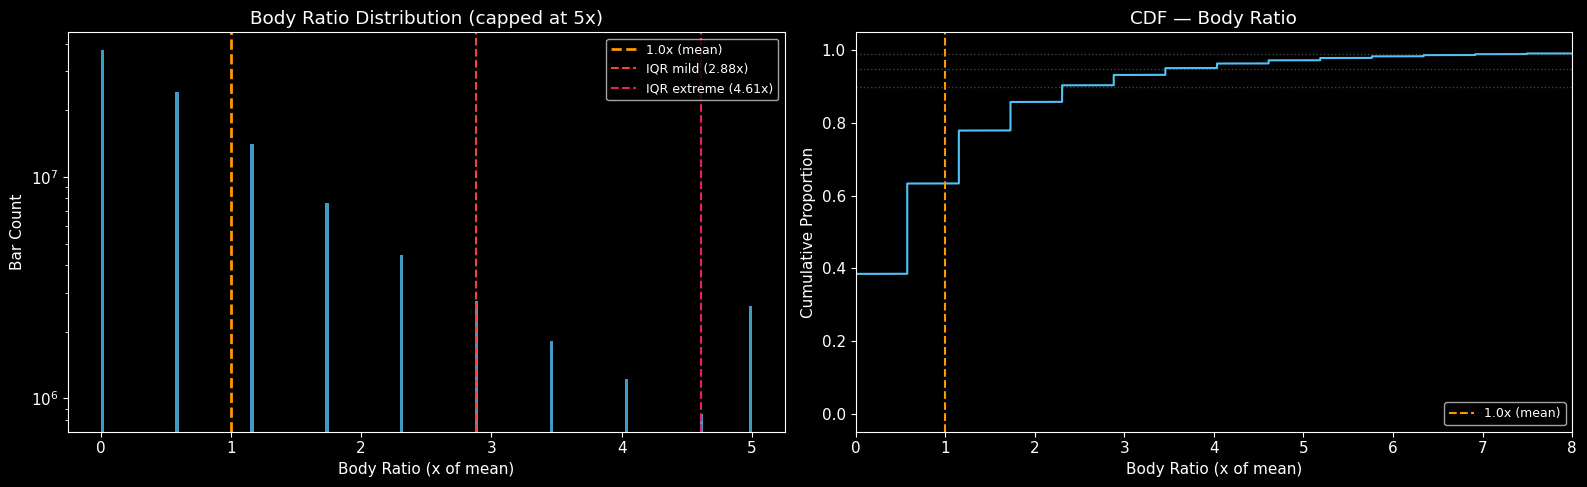

In [5]:
# Histogram of body_ratio — log scale to see the tail
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: full distribution (capped at 5x for visibility)
capped = np.clip(body_arr, 0, 5)
axes[0].hist(capped, bins=200, color='#4fc3f7', edgecolor='none', alpha=0.8)
axes[0].axvline(1.0, color='#ff9800', linestyle='--', linewidth=2, label='1.0x (mean)')
axes[0].axvline(mild, color='#f44336', linestyle='--', linewidth=1.5, label=f'IQR mild ({mild:.2f}x)')
axes[0].axvline(extreme, color='#e91e63', linestyle='--', linewidth=1.5, label=f'IQR extreme ({extreme:.2f}x)')
axes[0].set_xlabel('Body Ratio (x of mean)')
axes[0].set_ylabel('Bar Count')
axes[0].set_title('Body Ratio Distribution (capped at 5x)')
axes[0].legend(fontsize=9)
axes[0].set_yscale('log')

# Right: CDF — what % of bars are below each ratio
sorted_body = np.sort(body_arr[~np.isnan(body_arr)])
cdf = np.arange(1, len(sorted_body) + 1) / len(sorted_body)
axes[1].plot(sorted_body, cdf, color='#4fc3f7', linewidth=1.5)
axes[1].axvline(1.0, color='#ff9800', linestyle='--', linewidth=1.5, label='1.0x (mean)')
axes[1].axhline(0.90, color='gray', linestyle=':', linewidth=1, alpha=0.5)
axes[1].axhline(0.95, color='gray', linestyle=':', linewidth=1, alpha=0.5)
axes[1].axhline(0.99, color='gray', linestyle=':', linewidth=1, alpha=0.5)
axes[1].set_xlim(0, 8)
axes[1].set_xlabel('Body Ratio (x of mean)')
axes[1].set_ylabel('Cumulative Proportion')
axes[1].set_title('CDF — Body Ratio')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "body_ratio_distribution.png"), dpi=150, bbox_inches='tight')
plt.show()

## 3. Classify Bars + Cluster Analysis\nConsecutive runs of above-average bars reveal momentum vs noise.

In [6]:
# Classify every bar by body_ratio
df = df.with_columns([
    pl.when(pl.col("body_ratio") > 3.0).then(pl.lit("extreme"))
      .when(pl.col("body_ratio") > 2.0).then(pl.lit("outlier"))
      .when(pl.col("body_ratio") > 1.5).then(pl.lit("elevated"))
      .when(pl.col("body_ratio") > 1.0).then(pl.lit("above_avg"))
      .otherwise(pl.lit("normal"))
      .alias("body_class"),
    (pl.col("body_ratio") > 1.0).alias("is_above_avg"),
])

class_counts = df.group_by("body_class").agg(pl.len().alias("count")).sort("count", descending=True)
total = len(df)
print("BAR CLASSIFICATION (by body_ratio)")
print("=" * 50)
for row in class_counts.iter_rows(named=True):
    pct = 100.0 * row["count"] / total
    print(f"  {row['body_class']:>10}:  {row['count']:>12,}  ({pct:>5.1f}%)")

BAR CLASSIFICATION (by body_ratio)
      normal:    61,286,940  ( 63.4%)
   above_avg:    14,112,715  ( 14.6%)
    elevated:     7,623,567  (  7.9%)
     outlier:     7,193,642  (  7.4%)
     extreme:     6,518,765  (  6.7%)


In [7]:
# Cluster analysis — consecutive runs of above-average body bars
# Run-length encoding via diff-based grouping
above_avg = df["is_above_avg"].to_numpy().astype(np.int8)

# Find run boundaries
changes = np.diff(above_avg, prepend=-1) != 0
run_ids = np.cumsum(changes)

# Get run lengths for above-avg runs only
run_lengths = []
current_len = 0
current_val = above_avg[0]
for i in range(len(above_avg)):
    if i > 0 and run_ids[i] != run_ids[i-1]:
        if current_val == 1:
            run_lengths.append(current_len)
        current_len = 0
        current_val = above_avg[i]
    current_len += 1
if current_val == 1:
    run_lengths.append(current_len)

run_lengths = np.array(run_lengths)

print("CONSECUTIVE ABOVE-AVERAGE BODY RUNS")
print("=" * 55)
print(f"  Total runs:       {len(run_lengths):>10,}")
print(f"  Mean length:      {run_lengths.mean():>10.1f} bars")
print(f"  Median length:    {np.median(run_lengths):>10.0f} bars")
print(f"  Max length:       {run_lengths.max():>10,} bars")
print(f"  p90 length:       {np.percentile(run_lengths, 90):>10.0f} bars")
print(f"  p95 length:       {np.percentile(run_lengths, 95):>10.0f} bars")
print(f"  p99 length:       {np.percentile(run_lengths, 99):>10.0f} bars")

# Breakdown
total_above = above_avg.sum()
isolated = np.sum(run_lengths == 1)
short = np.sum((run_lengths >= 2) & (run_lengths <= 3))
medium = np.sum((run_lengths >= 4) & (run_lengths <= 10))
sustained = np.sum(run_lengths > 10)

# Bars in each category
bars_isolated = np.sum(run_lengths[run_lengths == 1])
bars_short = np.sum(run_lengths[(run_lengths >= 2) & (run_lengths <= 3)])
bars_medium = np.sum(run_lengths[(run_lengths >= 4) & (run_lengths <= 10)])
bars_sustained = np.sum(run_lengths[run_lengths > 10])

print(f"\nRun Type         Runs        Bars in Runs    % of Above-Avg Bars")
print(f"-" * 65)
print(f"  Isolated (1)   {isolated:>8,}    {bars_isolated:>12,}    {100*bars_isolated/total_above:>6.1f}%")
print(f"  Short (2-3)    {short:>8,}    {bars_short:>12,}    {100*bars_short/total_above:>6.1f}%")
print(f"  Medium (4-10)  {medium:>8,}    {bars_medium:>12,}    {100*bars_medium/total_above:>6.1f}%")
print(f"  Sustained (10+){sustained:>8,}    {bars_sustained:>12,}    {100*bars_sustained/total_above:>6.1f}%")

CONSECUTIVE ABOVE-AVERAGE BODY RUNS
  Total runs:       17,413,657
  Mean length:             2.0 bars
  Median length:             1 bars
  Max length:              302 bars


  p90 length:                4 bars
  p95 length:                6 bars
  p99 length:               11 bars



Run Type         Runs        Bars in Runs    % of Above-Avg Bars
-----------------------------------------------------------------
  Isolated (1)   10,082,592      10,082,592      28.4%
  Short (2-3)    5,160,111      11,909,593      33.6%
  Medium (4-10)  1,990,998      10,738,239      30.3%
  Sustained (10+) 179,956       2,718,265       7.7%


## 4. Time-of-Day Analysis — Mechanical vs Discretionary Zones\nWhen does real open-to-close movement happen vs algorithmic chop?

In [8]:
# Convert to Eastern Time and bucket into 30-minute intervals
df = df.with_columns([
    pl.col("timestamp").dt.convert_time_zone("US/Eastern").alias("ts_et"),
])

df = df.with_columns([
    pl.col("ts_et").dt.hour().alias("hour_et"),
    pl.col("ts_et").dt.minute().alias("minute_et"),
])

# 30-minute bucket label: "HH:MM"
df = df.with_columns([
    (pl.col("hour_et").cast(pl.Utf8).str.pad_start(2, "0") 
     + ":" 
     + (pl.col("minute_et") // 30 * 30).cast(pl.Utf8).str.pad_start(2, "0"))
    .alias("tod_bucket"),
])

# Session labels
df = df.with_columns([
    pl.when((pl.col("hour_et") >= 18) | (pl.col("hour_et") < 6)).then(pl.lit("overnight"))
      .when((pl.col("hour_et") >= 6) & (pl.col("hour_et") < 9)).then(pl.lit("pre_market"))
      .when((pl.col("hour_et") == 9) & (pl.col("minute_et") < 30)).then(pl.lit("pre_market"))
      .when((pl.col("hour_et") == 9) & (pl.col("minute_et") >= 30)).then(pl.lit("open"))
      .when((pl.col("hour_et") >= 10) & (pl.col("hour_et") < 12)).then(pl.lit("morning"))
      .when((pl.col("hour_et") >= 12) & (pl.col("hour_et") < 14)).then(pl.lit("lunch"))
      .when((pl.col("hour_et") >= 14) & (pl.col("hour_et") < 15)).then(pl.lit("afternoon"))
      .when((pl.col("hour_et") >= 15) & (pl.col("hour_et") < 16)).then(pl.lit("close"))
      .when((pl.col("hour_et") >= 16) & (pl.col("hour_et") < 18)).then(pl.lit("after_hours"))
      .otherwise(pl.lit("other"))
      .alias("session"),
])

print(f"Timezone-tagged {len(df):,} bars")

Timezone-tagged 96,735,629 bars


In [9]:
# Time-of-day stats table
tod = df.group_by("tod_bucket", "session").agg([
    pl.len().alias("n_bars"),
    pl.col("body_ratio").mean().alias("avg_body_ratio"),
    pl.col("body_ratio").median().alias("med_body_ratio"),
    pl.col("body_ratio").quantile(0.90).alias("p90_body_ratio"),
    pl.col("body_ratio").quantile(0.99).alias("p99_body_ratio"),
    pl.col("range_ratio").mean().alias("avg_range_ratio"),
    pl.col("volume_ratio").mean().alias("avg_vol_ratio"),
    (pl.col("body_z") > 2.0).mean().alias("pct_2sigma_outlier"),
    (pl.col("body_z") > 3.0).mean().alias("pct_3sigma_outlier"),
]).sort("tod_bucket")

print("TIME-OF-DAY BODY ANALYSIS (30-min buckets, Eastern Time)")
print("=" * 120)
print(f"{'Bucket':>7} {'Session':>12} {'Bars':>10} {'Avg Body':>10} {'Med Body':>10} {'p90':>8} {'p99':>8} {'Avg Range':>10} {'Avg Vol':>9} {'2sig%':>7} {'3sig%':>7}")
print("-" * 120)

for row in tod.iter_rows(named=True):
    print(f"  {row['tod_bucket']:>5} {row['session']:>12} {row['n_bars']:>10,} "
          f"{row['avg_body_ratio']:>9.3f}x {row['med_body_ratio']:>9.3f}x "
          f"{row['p90_body_ratio']:>7.2f}x {row['p99_body_ratio']:>7.2f}x "
          f"{row['avg_range_ratio']:>9.3f}x {row['avg_vol_ratio']:>8.2f}x "
          f"{100*row['pct_2sigma_outlier']:>6.1f}% {100*row['pct_3sigma_outlier']:>6.1f}%")

TIME-OF-DAY BODY ANALYSIS (30-min buckets, Eastern Time)
 Bucket      Session       Bars   Avg Body   Med Body      p90      p99  Avg Range   Avg Vol   2sig%   3sig%
------------------------------------------------------------------------------------------------------------------------
  00:00    overnight  2,182,391     0.744x     0.576x    1.73x    5.19x     0.686x     0.50x    1.6%    0.7%
  00:30    overnight  2,270,954     0.864x     0.576x    2.31x    6.34x     0.842x     0.66x    2.5%    1.1%
  01:00    overnight  2,434,690     0.861x     0.576x    2.31x    5.76x     0.833x     0.66x    2.1%    0.9%
  01:30    overnight  2,717,278     1.635x     1.153x    4.03x   10.95x     1.777x     2.06x    9.0%    4.7%
  02:00    overnight  2,737,332     1.358x     0.576x    3.46x    9.22x     1.450x     1.64x    6.1%    2.9%
  02:30    overnight  3,022,204     2.232x     1.729x    5.19x   11.53x     2.496x     3.32x   14.1%    7.0%
  03:00    overnight  2,995,922     1.866x     1.153x    4.

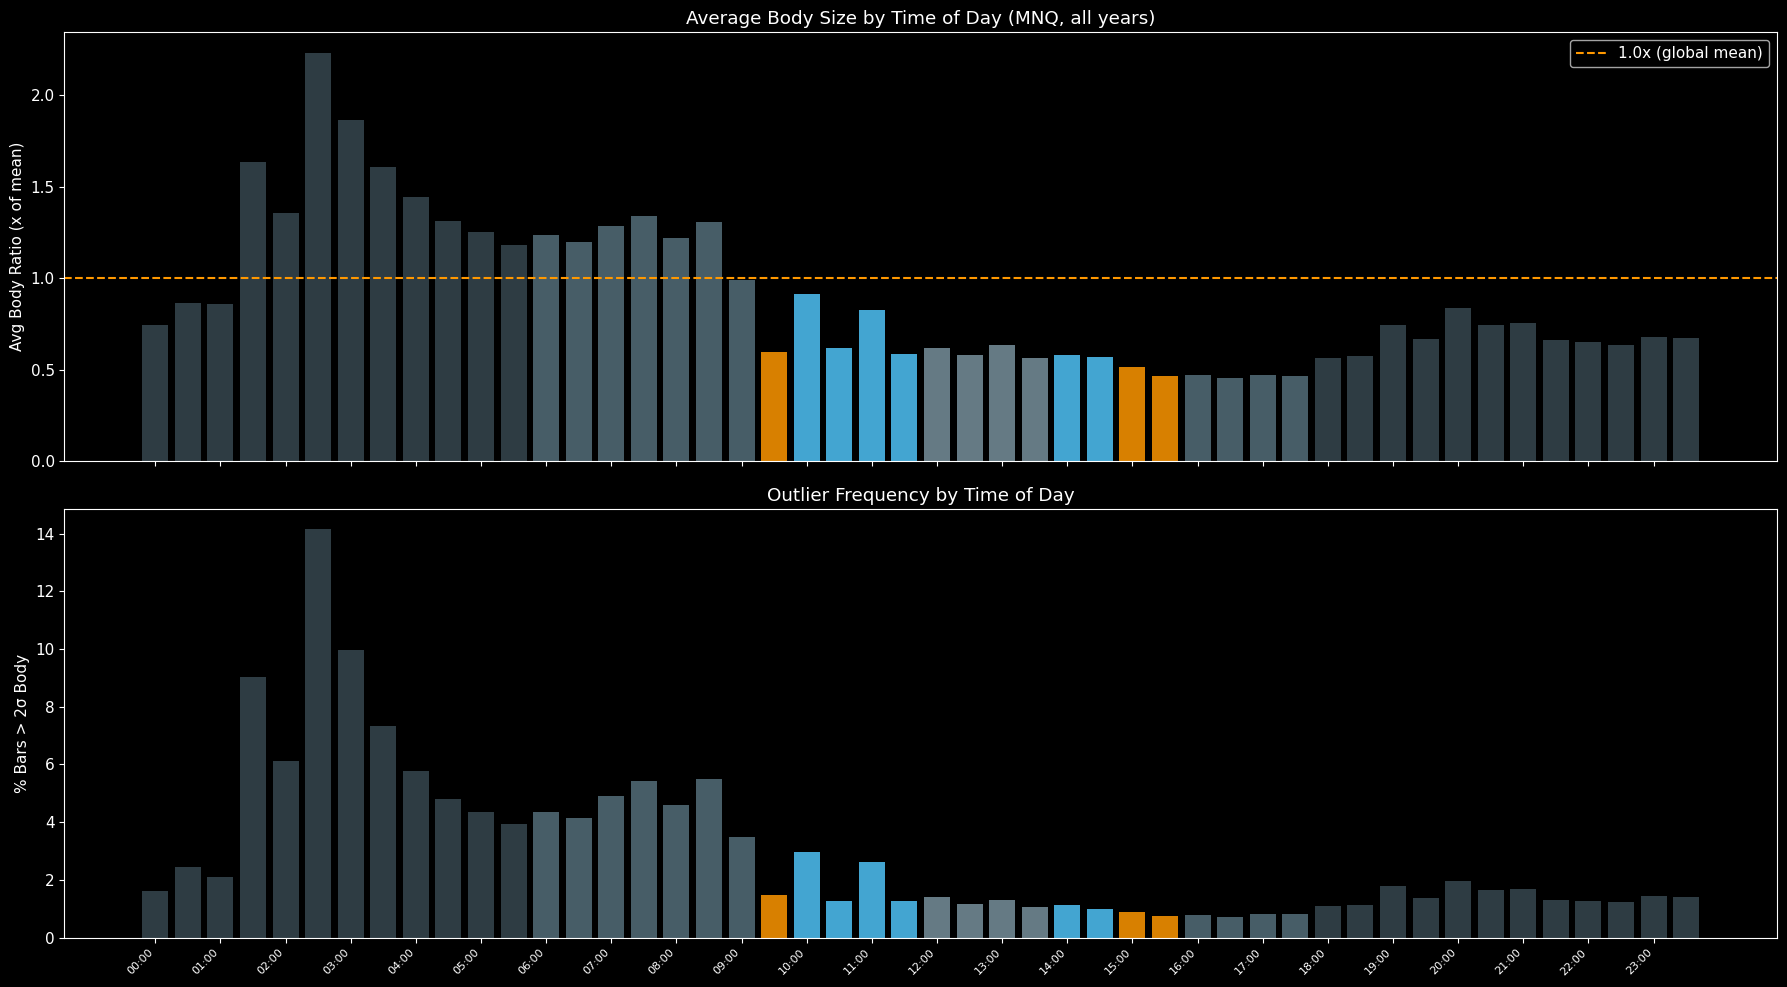

In [10]:
# Visual: time-of-day body ratio + outlier frequency
fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

buckets = tod["tod_bucket"].to_list()
x = np.arange(len(buckets))

# Color by session
session_colors = {
    "overnight": "#37474f", "pre_market": "#546e7a", "open": "#ff9800",
    "morning": "#4fc3f7", "lunch": "#78909c", "afternoon": "#4fc3f7",
    "close": "#ff9800", "after_hours": "#546e7a", "other": "#424242",
}
colors = [session_colors.get(s, "#424242") for s in tod["session"].to_list()]

# Top: average body ratio by time of day
axes[0].bar(x, tod["avg_body_ratio"].to_list(), color=colors, edgecolor='none', alpha=0.85)
axes[0].axhline(1.0, color='#ff9800', linestyle='--', linewidth=1.5, label='1.0x (global mean)')
axes[0].set_ylabel('Avg Body Ratio (x of mean)')
axes[0].set_title('Average Body Size by Time of Day (MNQ, all years)')
axes[0].legend()

# Bottom: % of bars that are 2sigma outliers
outlier_pcts = [100 * v for v in tod["pct_2sigma_outlier"].to_list()]
axes[1].bar(x, outlier_pcts, color=colors, edgecolor='none', alpha=0.85)
axes[1].set_ylabel('% Bars > 2σ Body')
axes[1].set_title('Outlier Frequency by Time of Day')
axes[1].set_xticks(x[::2])
axes[1].set_xticklabels([buckets[i] for i in range(0, len(buckets), 2)], rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "tod_body_analysis.png"), dpi=150, bbox_inches='tight')
plt.show()

## 5. Session-Level Summary — Mechanical vs Discretionary

In [11]:
# Session-level aggregation
session_order = ["overnight", "pre_market", "open", "morning", "lunch", "afternoon", "close", "after_hours"]

sess = df.group_by("session").agg([
    pl.len().alias("n_bars"),
    pl.col("body_ratio").mean().alias("avg_body_ratio"),
    pl.col("body_ratio").median().alias("med_body_ratio"),
    pl.col("body_ratio").quantile(0.90).alias("p90_body_ratio"),
    pl.col("range_ratio").mean().alias("avg_range_ratio"),
    pl.col("volume_ratio").mean().alias("avg_vol_ratio"),
    (pl.col("body_z") > 2.0).mean().alias("pct_2sigma"),
    (pl.col("body_z") > 3.0).mean().alias("pct_3sigma"),
    pl.col("body_pct_of_range").mean().alias("avg_body_pct"),
])

# Sort by session order
sess = sess.with_columns([
    pl.col("session").map_elements(
        lambda s: session_order.index(s) if s in session_order else 99, 
        return_dtype=pl.Int64
    ).alias("sort_key")
]).sort("sort_key").drop("sort_key")

print("SESSION SUMMARY — Mechanical vs Discretionary")
print("=" * 110)
print(f"{'Session':>12} {'Bars':>10} {'Avg Body':>10} {'Med Body':>10} {'p90':>8} {'Avg Vol':>9} {'Body%':>7} {'2sig%':>7} {'3sig%':>7}")
print("-" * 110)

for row in sess.iter_rows(named=True):
    regime = "MECH" if row["avg_body_ratio"] < 1.0 else "DISC"
    print(f"  {row['session']:>10} {row['n_bars']:>10,} "
          f"{row['avg_body_ratio']:>9.3f}x {row['med_body_ratio']:>9.3f}x "
          f"{row['p90_body_ratio']:>7.2f}x {row['avg_vol_ratio']:>8.2f}x "
          f"{100*row['avg_body_pct']:>6.1f}% "
          f"{100*row['pct_2sigma']:>6.1f}% {100*row['pct_3sigma']:>6.1f}%  [{regime}]")

print("\nMECH = avg body < 1.0x mean (mechanical/algo-dominated)")
print("DISC = avg body >= 1.0x mean (discretionary/human-driven)")

SESSION SUMMARY — Mechanical vs Discretionary
     Session       Bars   Avg Body   Med Body      p90   Avg Vol   Body%   2sig%   3sig%
--------------------------------------------------------------------------------------------------------------
   overnight 55,971,944     1.104x     0.576x    2.88x     1.18x   47.0%    4.3%    1.9%  [DISC]
  pre_market 17,186,012     1.244x     0.576x    2.88x     1.33x   50.7%    4.7%    2.1%  [DISC]
        open    933,231     0.595x     0.000x    1.73x     0.33x   37.1%    1.5%    0.7%  [MECH]
     morning  4,277,060     0.732x     0.000x    1.73x     0.36x   40.2%    2.1%    0.9%  [MECH]
       lunch  6,600,502     0.599x     0.000x    1.73x     0.35x   39.3%    1.2%    0.5%  [MECH]
   afternoon  3,438,391     0.574x     0.000x    1.73x     0.34x   39.3%    1.1%    0.4%  [MECH]
       close  2,960,918     0.492x     0.000x    1.15x     0.31x   36.1%    0.8%    0.3%  [MECH]
  after_hours  5,367,571     0.466x     0.000x    1.15x     0.30x   34.5%  

## 6. Regime Detection — Rolling Body Ratio Crossovers

In [12]:
# Rolling body ratio — when does it cross above 1.0 (mean)?
# This is the regime shift signal: mechanical -> discretionary

for window in [20, 50, 100]:
    col_name = f"body_ratio_ma{window}"
    df = df.with_columns([
        pl.col("body_ratio").rolling_mean(window_size=window).alias(col_name),
    ])

# Regime: rolling 20-bar body ratio above/below 1.0
df = df.with_columns([
    (pl.col("body_ratio_ma20") > 1.0).alias("regime_above_mean_20"),
    (pl.col("body_ratio_ma50") > 1.0).alias("regime_above_mean_50"),
])

# Stats
for window in [20, 50, 100]:
    col = f"body_ratio_ma{window}"
    above = df[col].to_numpy()
    valid = above[~np.isnan(above)]
    pct_above = 100.0 * np.sum(valid > 1.0) / len(valid)
    print(f"Rolling {window}-bar body ratio > 1.0x:  {pct_above:.1f}% of the time")

# Volume-body correlation
valid_mask = df["body_ratio"].is_not_nan() & df["volume_ratio"].is_not_nan()
df_valid = df.filter(valid_mask)
corr = np.corrcoef(df_valid["body_ratio"].to_numpy(), df_valid["volume_ratio"].to_numpy())[0, 1]
print(f"\nPearson correlation (body_ratio, volume_ratio): {corr:.4f}")

# Volume confirmation: what % of 2sigma body outliers also have above-avg volume?
outlier_mask = df["body_z"].to_numpy() > 2.0
vol_above = df["volume_ratio"].to_numpy() > 1.0
both = np.sum(outlier_mask & vol_above)
total_outliers = np.sum(outlier_mask)
if total_outliers > 0:
    print(f"Volume confirmation: {100*both/total_outliers:.1f}% of 2sigma body outliers also have above-avg volume")

Rolling 20-bar body ratio > 1.0x:  35.8% of the time


Rolling 50-bar body ratio > 1.0x:  35.7% of the time


Rolling 100-bar body ratio > 1.0x:  35.6% of the time



Pearson correlation (body_ratio, volume_ratio): 0.5636


Volume confirmation: 91.4% of 2sigma body outliers also have above-avg volume


In [13]:
# Regime transition detection — when does rolling 20-bar body ratio cross above 1.5x?
# These are the "spike" moments: market shifts from algo chop to real movement

ma20 = df["body_ratio_ma20"].to_numpy()
transitions_up = []  # indices where ma20 crosses from <1.5 to >=1.5

for i in range(1, len(ma20)):
    if not np.isnan(ma20[i]) and not np.isnan(ma20[i-1]):
        if ma20[i] >= 1.5 and ma20[i-1] < 1.5:
            transitions_up.append(i)

print(f"Total mechanical->discretionary transitions (ma20 crosses 1.5x): {len(transitions_up):,}")

# What time of day do these transitions happen?
if len(transitions_up) > 0:
    trans_hours = df["hour_et"].to_numpy()[transitions_up]
    trans_minutes = df["minute_et"].to_numpy()[transitions_up]
    trans_buckets = [f"{h:02d}:{(m // 30) * 30:02d}" for h, m in zip(trans_hours, trans_minutes)]
    
    from collections import Counter
    bucket_counts = Counter(trans_buckets)
    sorted_buckets = sorted(bucket_counts.items(), key=lambda x: x[1], reverse=True)
    
    print(f"\nTop 15 transition times (when body spikes begin):")
    print(f"{'Bucket':>8} {'Count':>8} {'% of Transitions':>18}")
    print("-" * 36)
    for bucket, count in sorted_buckets[:15]:
        print(f"  {bucket:>6} {count:>8,} {100*count/len(transitions_up):>16.1f}%")

Total mechanical->discretionary transitions (ma20 crosses 1.5x): 801,526



Top 15 transition times (when body spikes begin):
  Bucket    Count   % of Transitions
------------------------------------
   03:30   51,474              6.4%
   03:00   49,929              6.2%
   04:00   49,274              6.1%
   04:30   43,632              5.4%
   02:30   41,952              5.2%
   05:00   39,300              4.9%
   07:30   35,642              4.4%
   07:00   34,839              4.3%
   05:30   34,334              4.3%
   06:00   33,940              4.2%
   06:30   31,364              3.9%
   08:30   30,802              3.8%
   08:00   29,803              3.7%
   02:00   29,108              3.6%
   01:30   25,656              3.2%


## 7. 5-Minute and 15-Minute Timeframe Analysis

In [14]:
# Resample to 5m and 15m, repeat body ratio analysis
def analyze_timeframe(df_tf, label):
    body = (df_tf["close"] - df_tf["open"]).abs()
    rng = df_tf["high"] - df_tf["low"]
    bm = body.mean()
    bs = body.std()
    body_ratio = body / bm
    body_z = (body - bm) / bs
    body_pct = pl.when(rng > 0).then(body / rng).otherwise(0.0)
    
    br = body_ratio.to_numpy()
    
    print(f"\n{'='*70}")
    print(f"{label} — {len(df_tf):,} bars")
    print(f"{'='*70}")
    
    for p in [0.50, 0.75, 0.90, 0.95, 0.99]:
        v = np.nanquantile(br, p)
        print(f"  p{int(p*100):>2}: {v:.3f}x mean")
    
    # Sigma thresholds
    for sigma in [1, 2, 3]:
        thresh = 1.0 + sigma * (bs / bm)
        pct = 100 * np.sum(br > thresh) / len(br)
        print(f"  +{sigma}σ = {thresh:.3f}x  ({pct:.2f}%)")
    
    # Outlier clustering  
    above = (br > 1.0).astype(np.int8)
    changes = np.diff(above, prepend=-1) != 0
    rids = np.cumsum(changes)
    runs = []
    cl, cv = 0, above[0]
    for i in range(len(above)):
        if i > 0 and rids[i] != rids[i-1]:
            if cv == 1: runs.append(cl)
            cl, cv = 0, above[i]
        cl += 1
    if cv == 1: runs.append(cl)
    runs = np.array(runs)
    
    if len(runs) > 0:
        print(f"  Above-avg runs: mean={runs.mean():.1f}, med={np.median(runs):.0f}, max={runs.max()}, p95={np.percentile(runs,95):.0f}")

# 5-minute
df_5m = df.sort("timestamp").group_by_dynamic("timestamp", every="5m").agg([
    pl.col("open").first(),
    pl.col("high").max(),
    pl.col("low").min(),
    pl.col("close").last(),
    pl.col("volume").sum(),
])
analyze_timeframe(df_5m, "5-MINUTE BARS")

# 15-minute
df_15m = df.sort("timestamp").group_by_dynamic("timestamp", every="15m").agg([
    pl.col("open").first(),
    pl.col("high").max(),
    pl.col("low").min(),
    pl.col("close").last(),
    pl.col("volume").sum(),
])
analyze_timeframe(df_15m, "15-MINUTE BARS")


5-MINUTE BARS — 469,851 bars
  p50: 0.563x mean
  p75: 1.232x mean
  p90: 2.359x mean
  p95: 3.450x mean
  p99: 6.654x mean
  +1σ = 2.427x  (9.64%)
  +2σ = 3.855x  (3.91%)
  +3σ = 5.282x  (1.83%)
  Above-avg runs: mean=2.0, med=1, max=38, p95=6



15-MINUTE BARS — 156,663 bars
  p50: 0.565x mean
  p75: 1.231x mean
  p90: 2.341x mean
  p95: 3.411x mean
  p99: 6.599x mean
  +1σ = 2.406x  (9.52%)
  +2σ = 3.811x  (3.97%)
  +3σ = 5.217x  (1.87%)
  Above-avg runs: mean=2.0, med=1, max=42, p95=5


## 8. Save Results

In [15]:
# Save key results as JSON
results = {
    "symbol": "MNQ",
    "total_bars": len(df),
    "date_range": [str(df["timestamp"].min()), str(df["timestamp"].max())],
    "body_ratio_percentiles": {
        f"p{int(p*100)}": float(np.nanquantile(body_arr, p))
        for p in [0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.999]
    },
    "sigma_thresholds": {
        f"+{s}sigma": float(1.0 + s * (body_std / body_mean))
        for s in [1, 1.5, 2, 3]
    },
    "iqr_thresholds": {
        "mild": float(mild),
        "extreme": float(extreme),
    },
    "session_avg_body_ratio": {
        row["session"]: float(row["avg_body_ratio"])
        for row in sess.iter_rows(named=True)
    },
    "volume_body_correlation": float(corr),
    "cluster_stats": {
        "mean_run_length": float(run_lengths.mean()),
        "median_run_length": float(np.median(run_lengths)),
        "max_run_length": int(run_lengths.max()),
        "p95_run_length": float(np.percentile(run_lengths, 95)),
    },
}

with open(OUTPUT_DIR / "summary_stats.json", "w") as f:
    json.dump(results, f, indent=2)

# Save TOD stats
tod.write_json(str(OUTPUT_DIR / "tod_stats.json"))

print(f"Results saved to {OUTPUT_DIR}")
print(f"  summary_stats.json")
print(f"  tod_stats.json")
print(f"  body_ratio_distribution.png")
print(f"  tod_body_analysis.png")

Results saved to E:\source\repos\ml_dashboard\data\candle_analysis\MNQ
  summary_stats.json
  tod_stats.json
  body_ratio_distribution.png
  tod_body_analysis.png
